# Klasyfikacja zaburzeń rytmu serca na podstawie sygnału EKG przy użyciu modeli uczenia maszynowego

## Cel projektu

Celem niniejszego badania jest stworzenie modelu klasyfikacyjnego zdolnego do automatycznego rozpoznawania typów uderzeń serca. Automatyzacja tego procesu wspiera diagnostykę kardiologiczną poprzez szybką identyfikację stanów patologicznych.

## Źródło danych

Wykorzystano bazę danych MIT-BIH Arrhythmia Database - jeden z najczęściej stosowanych zbiorów referencyjnych w badaniach nad automatyczną analizą EKG. Baza została opracowana przez Massachusetts Institute of Technology i Boston's Beth Israel Hospital w latach 1975–1979 i zawiera 48 półgodzinnych zapisów EKG z dwóch odprowadzeń, pozyskanych od 47 pacjentów (Moody & Mark, 2001).

Dane w formacie przetworzonym (segmenty pojedynczych uderzeń) pochodzą z repozytorium Kaggle: [ECG Heartbeat Categorization Dataset](https://www.kaggle.com/datasets/shayanfazeli/heartbeat), gdzie zostały przygotowane zgodnie z metodologią opisaną przez Kachuee et al. (2018). Każdy segment zawiera 187 próbek reprezentujących znormalizowaną amplitudę sygnału wokół załamka R.

## Klasyfikacja AAMI

Zgodnie z rekomendacjami Association for the Advancement of Medical Instrumentation (AAMI), oryginalne adnotacje zostały zgrupowane w 5 klas superklasowych:

| Klasa | Nazwa | Zawartość |
|-------|-------|--------|
| 0 | N (Normal) | Rytm prawidłowy, blok odnogi pęczka Hisa, pobudzenia ucieczkowe |
| 1 | S (Supraventricular) | Przedwczesne pobudzenia przedsionkowe i nadkomorowe |
| 2 | V (Ventricular) | Przedwczesne skurcze komorowe, pobudzenia ucieczkowe komorowe |
| 3 | F (Fusion) | Pobudzenia zlane (fuzja pobudzenia normalnego i komorowego) |
| 4 | Q (Unknown) | Pobudzenia stymulowane, nieklasyfikowalne |

## Wybór metod

W projekcie zastosowano dwa podejścia:

1. Regresja logistyczna (OvR) — klasyczna metoda ML, wybrana ze względu na interpretowalność, szybkość treningu i dobre wyniki na zbilansowanych danych. Zastosowano ważenie klas aby przeciwdziałać silnemu niezbalansowaniu.

2. Płytka sieć neuronowa (MLP) — prosta architektura feedforward jako punkt odniesienia dla metod głębokiego uczenia. Mimo że literatura wskazuje na wyższość sieci konwolucyjnych (CNN) dla sygnałów czasowych, MLP pozwala ocenić wartość dodaną cech inżynierskich.

## Literatura

- Moody, G. B., & Mark, R. G. (2001). The impact of the MIT-BIH Arrhythmia Database. *IEEE Engineering in Medicine and Biology Magazine*, 20(3), 45–50.
- Kachuee, M., Fazeli, S., & Sarrafzadeh, M. (2018). ECG Heartbeat Classification: A Deep Transferable Representation. *IEEE International Conference on Healthcare Informatics*.
- Acharya, U. R., et al. (2017). A deep convolutional neural network model to classify heartbeats. *Computers in Biology and Medicine*, 89, 389–396.
- de Chazal, P., O'Dwyer, M., & Reilly, R. B. (2004). Automatic classification of heartbeats using ECG morphology and heartbeat interval features. *IEEE Transactions on Biomedical Engineering*, 51(7), 1196–1206.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

classes_description = ["0. Normal, Left/Right bundle branch block, Atrial escape, Nodal escape",
           "1. Atrial premature, Aberrant atrial premature, Nodal premature, Supra-ventricular premature",
           "2. Premature ventricular contraction, Ventricular escape",
           "3. Fusion of ventricular and norma",
           "4. Paced, Fusion of paced and normal, Unclassifiable"]

Dane są ładowane z plików CSV. Ostatnia kolumna stanowi etykietę klasy, natomiast pozostałe kolumny to znormalizowane wartości amplitudy sygnału EKG w czasie.

In [4]:
train_path = "mitbih_train.csv"
train_data = pd.read_csv(train_path, header=None, usecols=range(188))

X_train = train_data.iloc[:, :-1]
y_train = train_data.iloc[:, -1]

In [5]:
len(y_train), X_train.shape

(87554, (87554, 187))

In [6]:
test_path = "mitbih_test.csv"
test_data = pd.read_csv(test_path, header=None, usecols=range(188))

X_test = test_data.iloc[:, :-1]
y_test = test_data.iloc[:, -1]


Poniższe wykresy prezentują przykładowe przebiegi sygnału EKG dla każdej z pięciu klas. Pozwala to na wstępną ocenę morfologii załamków charakterystycznych dla poszczególnych schorzeń (np. wyraźnie inne kształty zespołu QRS w klasie 2).

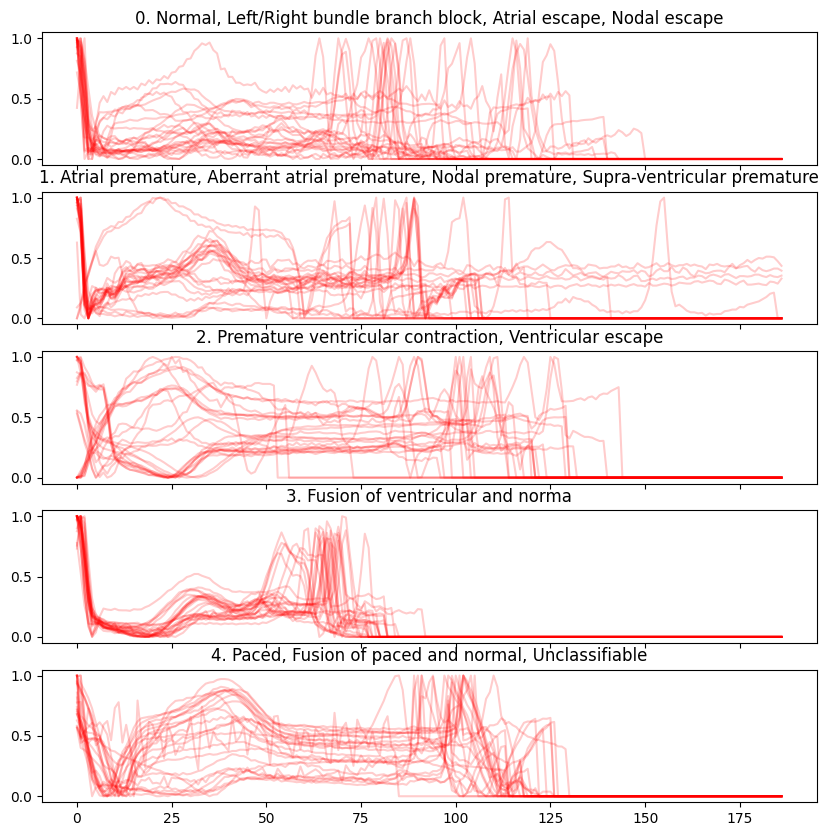

In [7]:
def plot(x_data, y_data, classes_description=classes_description, plots_per_class=25):
    classes = range(len(classes_description))
    f, ax = plt.subplots(len(classes), sharex=True, sharey=True, figsize=(10,10))
    for i in classes:
        for j in range(plots_per_class):
            ax[i].set_title(classes_description[i])
            
            # jesli y_data (wynik) jest rowny rysowanej klasie to rysuj jego x_data (caly ten wiersz)
            ax[i].plot(x_data[y_data == i].iloc[j, :], color="red", alpha=.2)
            
plot(X_train, y_train)

Standardowe wykresy liniowe przy dużej skali danych stają się nieczytelne. Aby uzyskać pełny obraz charakterystyki sygnału dla poszczególnych klas, stosujemy mapę ciepła.

- oś X: Przedstawia przebieg sygnału EKG w czasie,
- oś Y: Kolejne wiersze z zestawu danych reprezentujące oddzielne uderzenia serca,
- intensywność koloru: Reprezentuje amplitudę sygnału

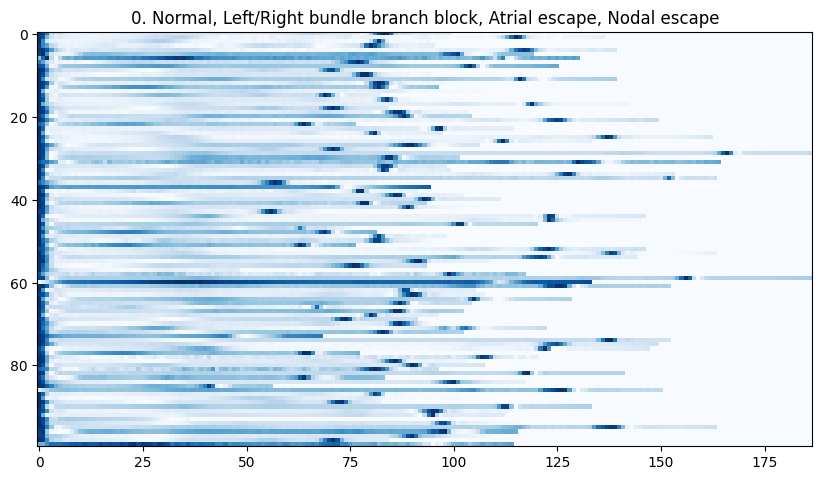

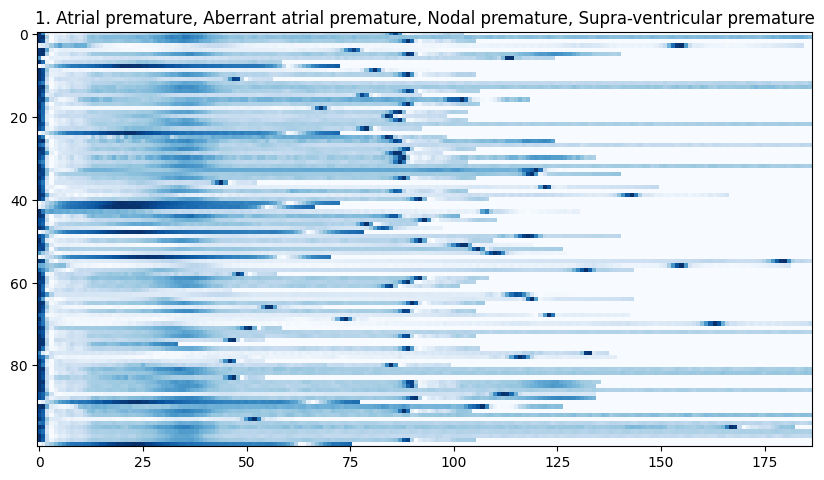

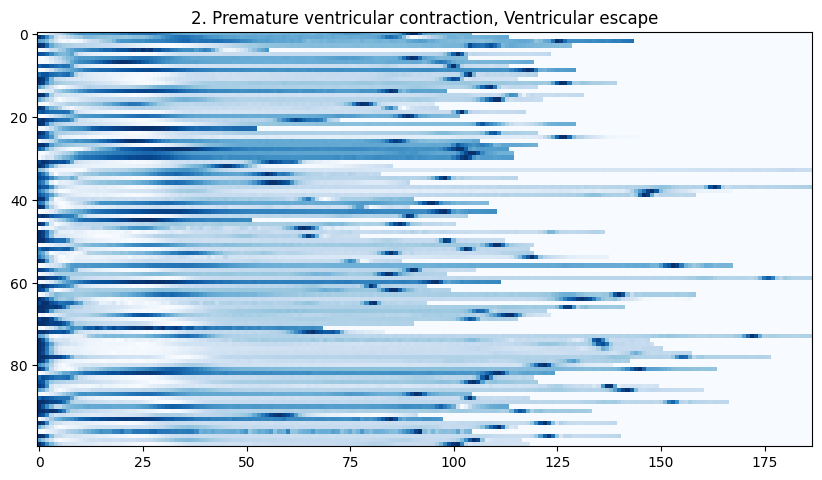

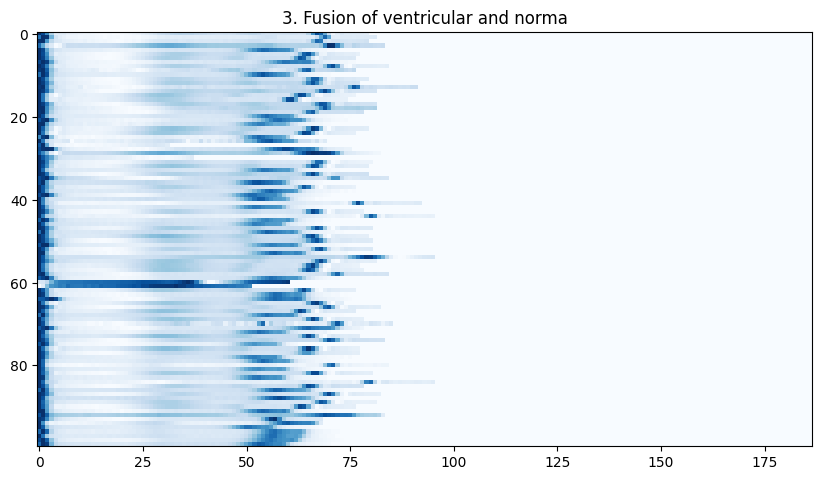

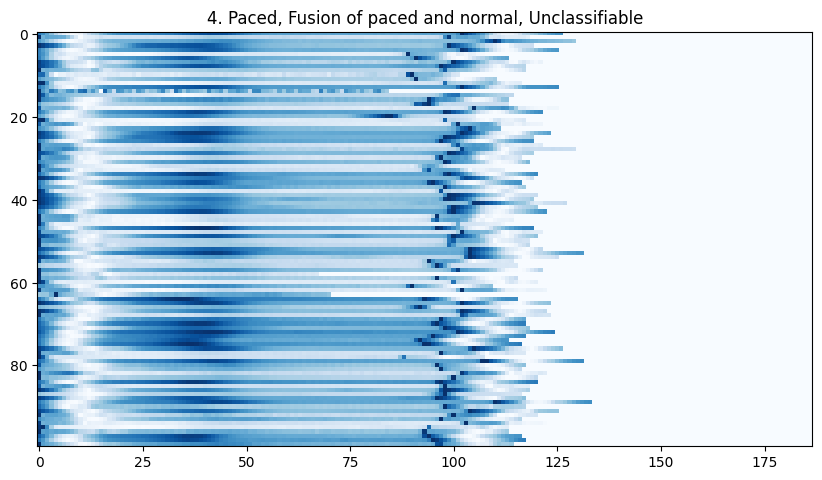

In [8]:
def class_spec(data, classnumber, n_samples):

    fig = plt.figure(figsize=(10,13))
    if type(data)==pd.DataFrame: 
        # wez wszystkie wiersze data gdzie jest szukany class number a nastepnie n_samples wierszy       
        plt.imshow(data[y_train==classnumber].iloc[:n_samples,:], 
               cmap="Blues", interpolation="nearest")
    else:
        plt.imshow(data[y_train==classnumber][:n_samples,:], 
               cmap="Blues", interpolation="nearest")
    plt.title(classes_description[i])
    plt.show()
    
for i in range(len(classes_description)):
    class_spec(X_train, i, 100)

### Filtracja sygnału

Surowy sygnał EKG zawiera zakłócenia wysokoczęstotliwościowe (drżenie mięśni, szum sieciowy). Stosujemy filtrację Gaussa, która jest standardową techniką wstępnego przetwarzania w analizie EKG (Acharya et al., 2017). Wygładzanie redukuje szum przy zachowaniu morfologii załamków diagnostycznych (P, QRS, T).

In [9]:
from scipy.signal.windows import gaussian
from scipy.signal import decimate
from scipy.sparse import csr_matrix

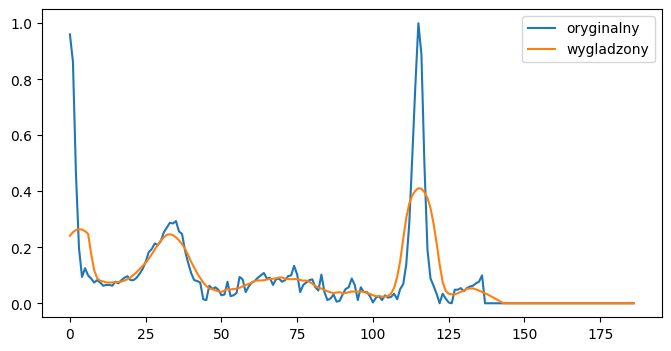

In [10]:
def gaussian_smoothing(data, window, std):
    gauss = gaussian(window, std, sym=True)
    data = np.convolve(gauss/gauss.sum(), data, mode='same')
    return data

def gauss_wrapper(data):
    return gaussian_smoothing(data, 12, 7)

fig = plt.figure(figsize=(8,4))
plt.plot(X_train.iloc[1,:], label="oryginalny")
plt.plot(gauss_wrapper(X_train.iloc[1,:]), label="wygladzony")
plt.legend()

### Inżynieria cech (Feature Engineering)

Rozszerzamy reprezentację sygnału o cechy pochodne:
- Pierwsza pochodna — prędkość zmian napięcia, uwypukla strome zbocza zespołu QRS
- Druga pochodna — przyspieszenie zmian, wyostrza punkty przegięcia

Takie podejście jest zgodne z literaturą — de Chazal et al. (2004) pokazali, że cechy morfologiczne znacząco poprawiają klasyfikację w porównaniu do surowego sygnału.

C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)


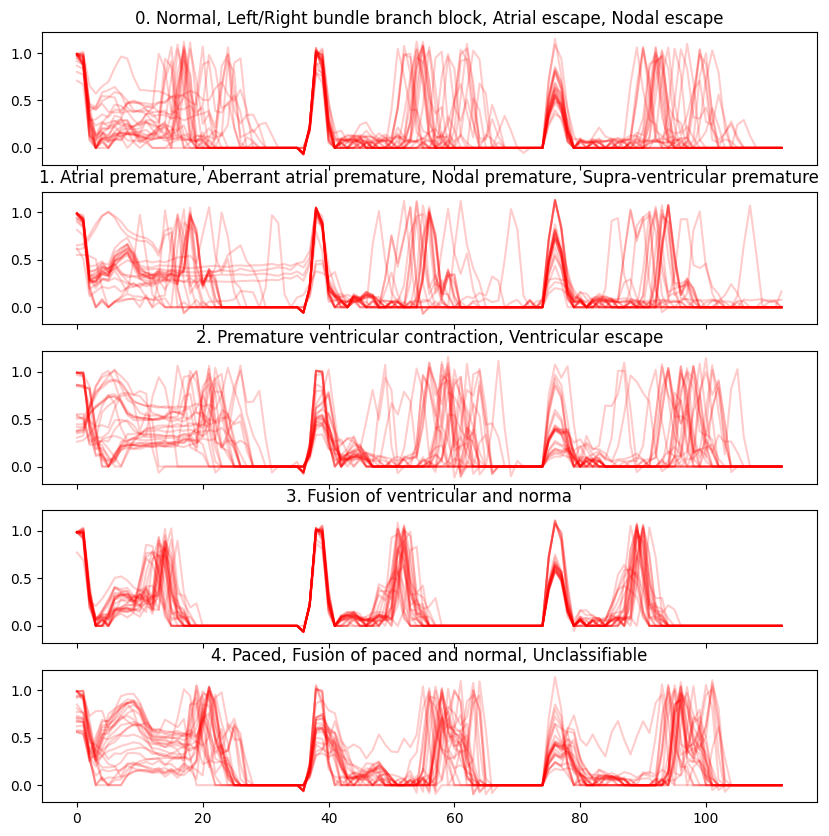

In [11]:
def gradient(data, normalize=True):
    data = data.diff(axis=1, periods=3)
    if normalize:
        data = data.apply(lambda x: x/x.abs().max(), axis=1)
    return data

def preprocess(data): 
    data = data.abs().rolling(7, axis=1).max()
    data = data.fillna(method="bfill",axis=1)
    data = decimate(data, axis=1, q=5)
    data[np.abs(data) < .05] = 0
    return pd.DataFrame(data)

x_train_grad = gradient(X_train)
x_test_grad = gradient(X_test)

x_train_preprocessed = preprocess(pd.concat([X_train, x_train_grad, gradient(x_train_grad)], axis=1))
x_test_preprocessed = preprocess(pd.concat([X_test, x_test_grad, gradient(x_test_grad)], axis=1))

plot(x_train_preprocessed, y_train)

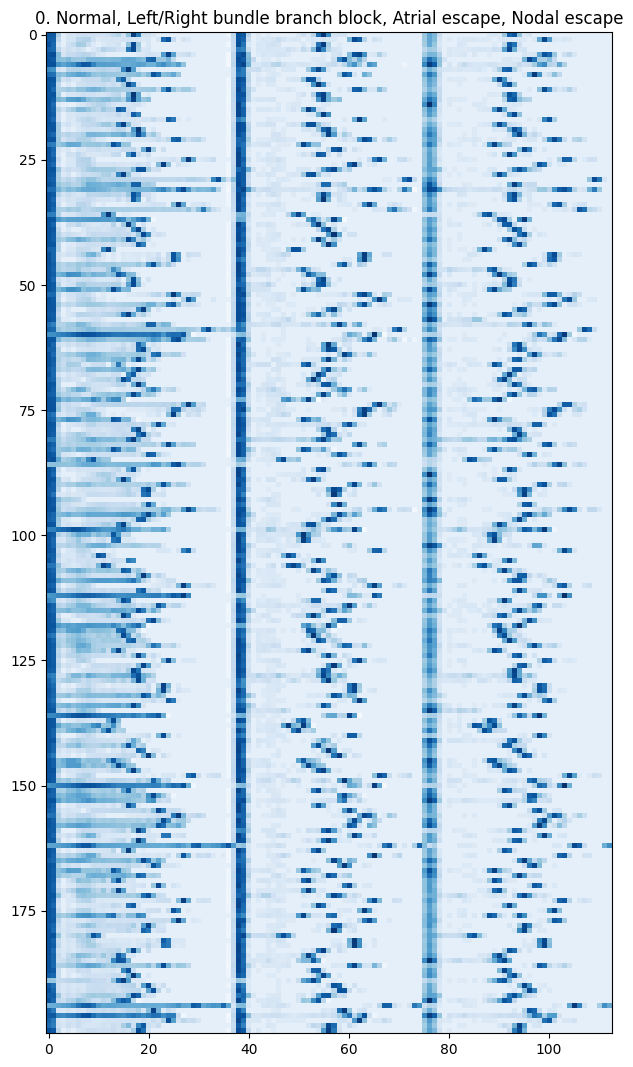

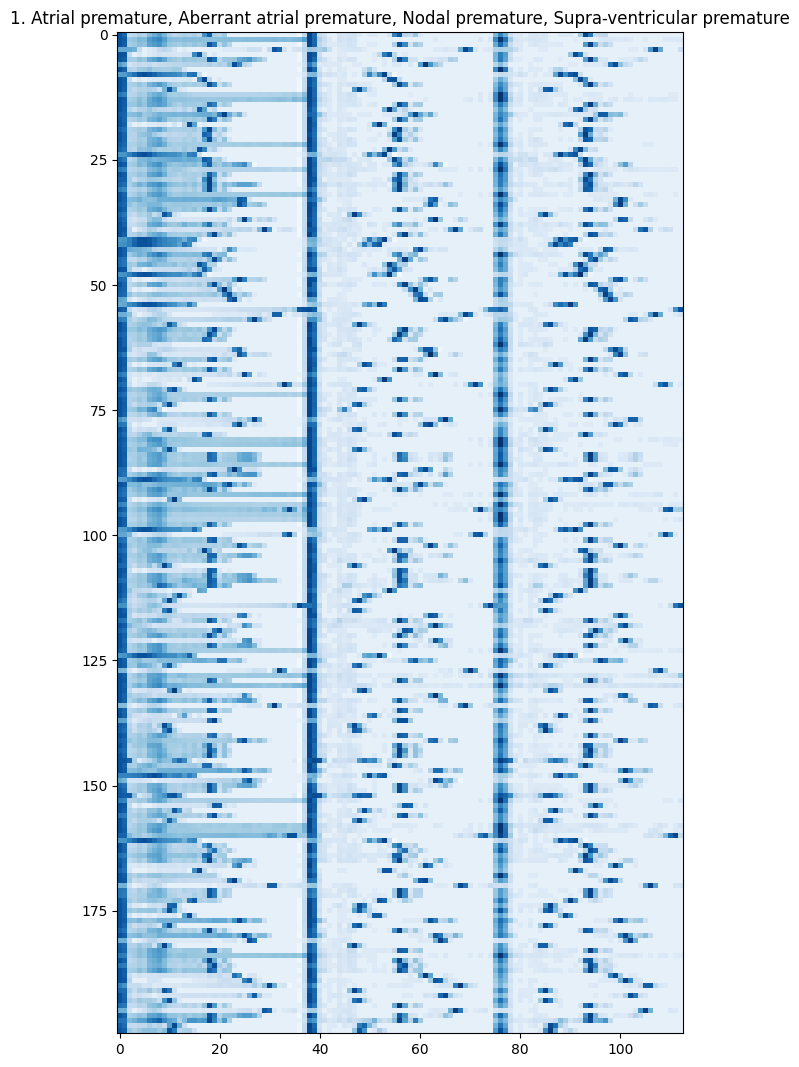

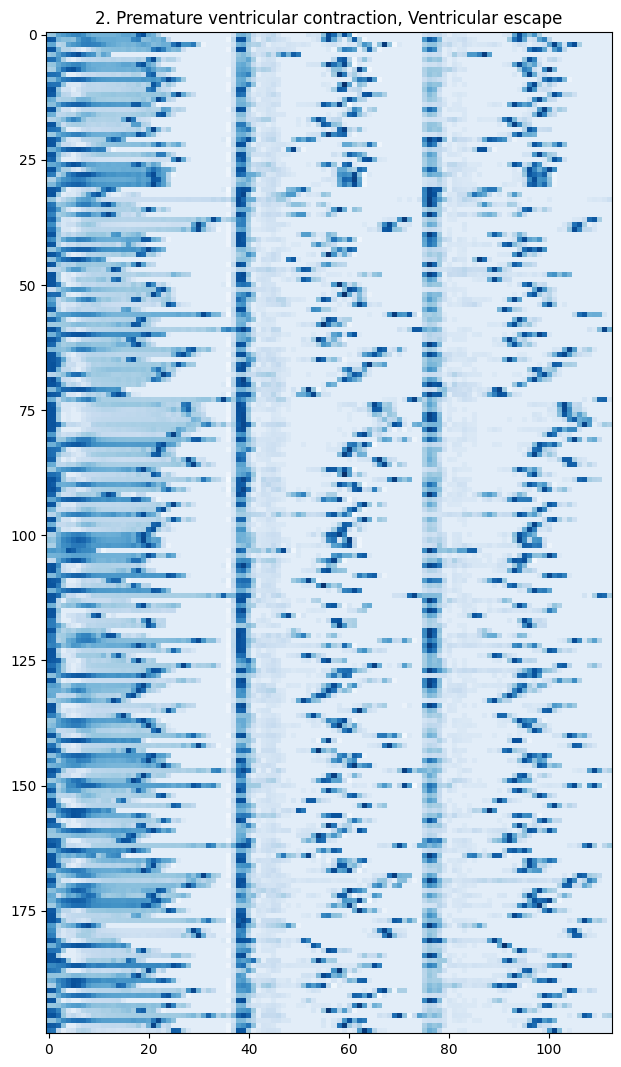

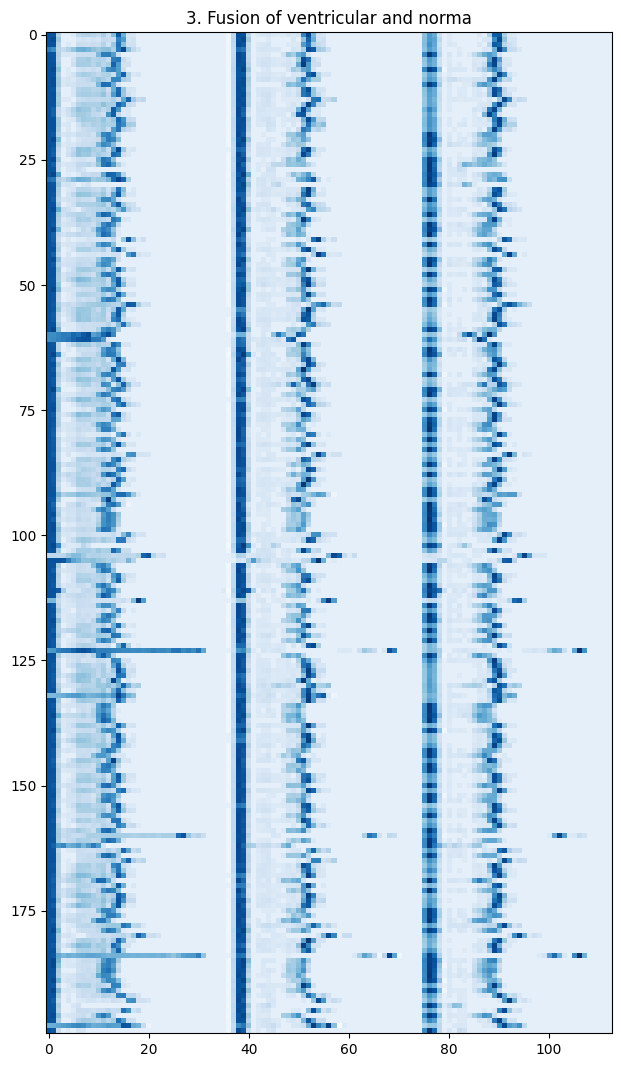

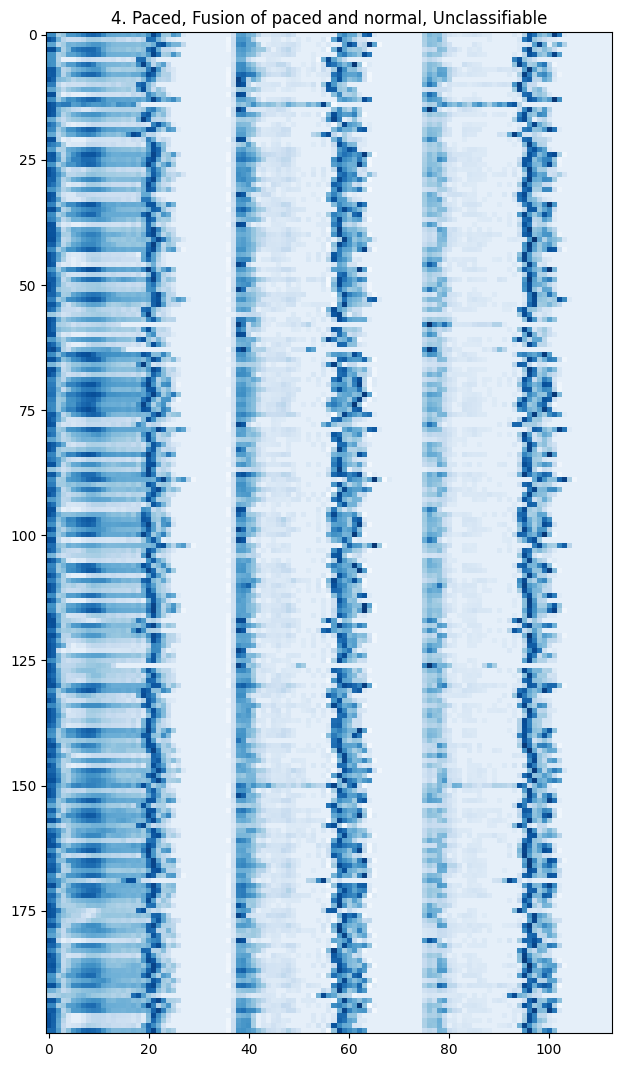

In [12]:
for i in range(len(classes_description)):
    class_spec(x_train_preprocessed, i, 200)

In [13]:
import time
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import classification_report

## Model 1: Regresja logistyczna

Stosujemy regresję logistyczną z podejściem One-vs-Rest (OvR) — osobny klasyfikator binarny dla każdej klasy. Parametry:
- `solver='newton-cg'` — metoda Newtona, efektywna dla dużych zbiorów
- `class_weight='balanced'` — kompensacja niezbalansowania klas
- `C=0.5` — umiarkowana regularyzacja L2 zapobiegająca przeuczeniu

In [14]:
model = LogisticRegression(multi_class="ovr",solver="newton-cg", class_weight="balanced",
                          n_jobs=2, max_iter=150, C=.5)

x_train_sparse = csr_matrix(x_train_preprocessed)
start_time = time.time()
model.fit(x_train_sparse,y_train)
print("training time {}".format(time.time()-start_time))

c:\Users\HARDPC\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:1281: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(


training time 3.762240409851074


Zapis modelu:

In [15]:
from joblib import dump

dump(model, 'ekg_model.joblib')

['ekg_model.joblib']

In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

x_test_sparse = csr_matrix(x_test_preprocessed)
y_pred = model.predict(x_test_sparse)


print("METRYKI MODELU")

print(f"Dokładność:       {accuracy_score(y_test, y_pred):.2%}")
print(f"Precyzja (macro): {precision_score(y_test, y_pred, average='macro', zero_division=0):.2%}")
print(f"Recall (macro):   {recall_score(y_test, y_pred, average='macro', zero_division=0):.2%}")
print(f"F1-Score (macro): {f1_score(y_test, y_pred, average='macro', zero_division=0):.2%}")



METRYKI MODELU
Dokładność:       88.32%
Precyzja (macro): 60.42%
Recall (macro):   81.75%
F1-Score (macro): 65.41%


## Analiza wyników — Macierz pomyłek

Sama dokładność (accuracy) nie wystarcza do oceny modelu przy silnie niezbalansowanych klasach. Macierz pomyłek pozwala zidentyfikować, które klasy są mylone ze sobą i gdzie model popełnia błędy kliniczne znaczące.

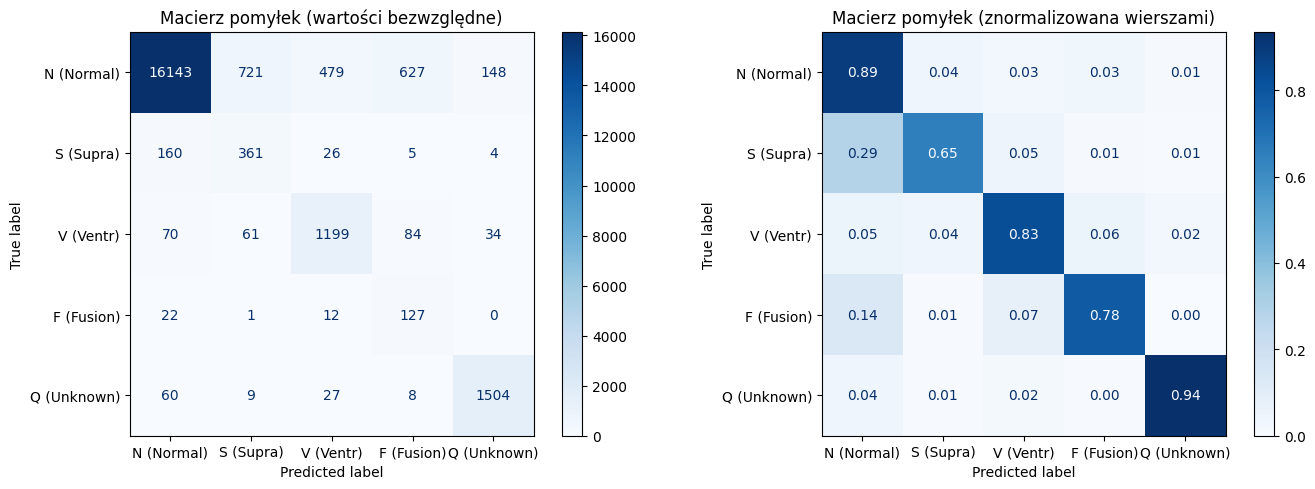

In [17]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

cm = confusion_matrix(y_test, y_pred)

class_names = ['N (Normal)', 'S (Supra)', 'V (Ventr)', 'F (Fusion)', 'Q (Unknown)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

disp1 = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp1.plot(ax=axes[0], cmap='Blues', values_format='d')
axes[0].set_title('Macierz pomyłek (wartości bezwzględne)')

cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_normalized, display_labels=class_names)
disp2.plot(ax=axes[1], cmap='Blues', values_format='.2f')
axes[1].set_title('Macierz pomyłek (znormalizowana wierszami)')

plt.tight_layout()
plt.show()

### Interpretacja macierzy pomyłek

**Klasa N (Normal)** — najliczniejsza klasa, rozpoznawana z bardzo wysoką skutecznością. Większość błędów to fałszywe pozytywy z innych klas mylonych z N.

**Klasa S (Supraventricular)** — najsłabiej rozpoznawana. Wiele przypadków mylonych z klasą N, co wynika z podobnej morfologii pobudzeń przedsionkowych do prawidłowych. Jest to zgodne z literaturą — de Chazal et al. (2004) również raportowali trudności z tą klasą.

**Klasa V (Ventricular)** — dobra rozpoznawalność dzięki charakterystycznej, szerokiej morfologii zespołu QRS. Klinicznie istotne, ponieważ arytmie komorowe mogą zagrażać życiu.

**Klasa F (Fusion)** — niska rozpoznawalność ze względu na małą liczebność próbek i hybrydowy charakter (cechy zarówno N jak i V).

**Klasa Q (Unknown)** — umiarkowana rozpoznawalność. Heterogeniczna kategoria obejmująca różne typy pobudzeń.

In [18]:
from sklearn.metrics import classification_report
import pandas as pd

report = classification_report(y_test, y_pred, target_names=class_names, output_dict=True)
report_df = pd.DataFrame(report).transpose()

print("Metryki dla poszczególnych klas:")
print(report_df.iloc[:5].round(3).to_string())
print("\n" + "="*60)
print(f"\nMakro-średnia F1: {report_df.loc['macro avg', 'f1-score']:.3f}")
print(f"Ważona-średnia F1: {report_df.loc['weighted avg', 'f1-score']:.3f}")

Metryki dla poszczególnych klas:
             precision  recall  f1-score  support
N (Normal)       0.981   0.891     0.934  18118.0
S (Supra)        0.313   0.649     0.422    556.0
V (Ventr)        0.688   0.828     0.751   1448.0
F (Fusion)       0.149   0.784     0.251    162.0
Q (Unknown)      0.890   0.935     0.912   1608.0


Makro-średnia F1: 0.654
Ważona-średnia F1: 0.902


### Wpływ niezbalansowania klas

Rozkład klas w zbiorze treningowym jest silnie nierównomierny:

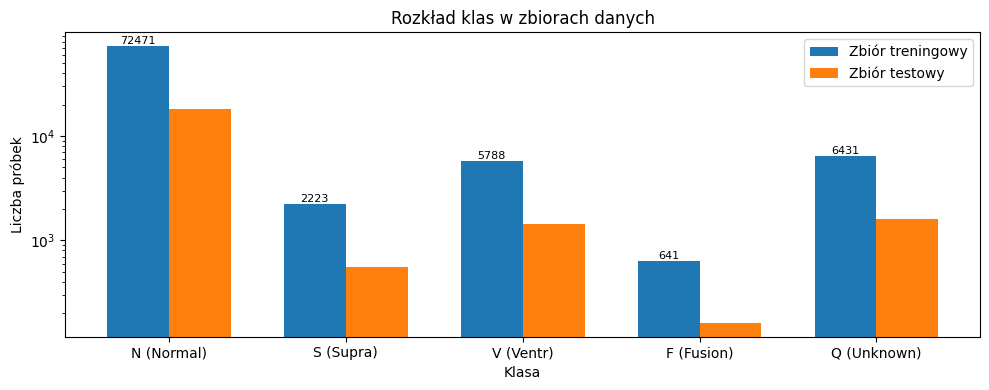


Stosunek klasy N do najmniejszej klasy (F): 113:1


In [19]:
import matplotlib.pyplot as plt
import numpy as np

class_counts_train = np.bincount(y_train.astype(int))
class_counts_test = np.bincount(y_test.astype(int))

fig, ax = plt.subplots(figsize=(10, 4))
x = np.arange(5)
width = 0.35

bars1 = ax.bar(x - width/2, class_counts_train, width, label='Zbiór treningowy')
bars2 = ax.bar(x + width/2, class_counts_test, width, label='Zbiór testowy')

ax.set_ylabel('Liczba próbek')
ax.set_xlabel('Klasa')
ax.set_title('Rozkład klas w zbiorach danych')
ax.set_xticks(x)
ax.set_xticklabels(class_names)
ax.legend()
ax.set_yscale('log')

for bar, count in zip(bars1, class_counts_train):
    ax.annotate(f'{count}', xy=(bar.get_x() + bar.get_width()/2, bar.get_height()),
                ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

print(f"\nStosunek klasy N do najmniejszej klasy (F): {class_counts_train[0]/class_counts_train[3]:.0f}:1")

## Model 2: Sieć neuronowa (MLP)

Jako alternatywę stosujemy płytką sieć feedforward (Multi-Layer Perceptron). Architektura:
- Warstwa wejściowa: 561 neuronów (3×187 cech)
- Warstwa ukryta 1: 64 neurony, ReLU
- Warstwa ukryta 2: 32 neurony, ReLU
- Warstwa wyjściowa: 5 neuronów (softmax)

MLP może uchwycić nieliniowe zależności między cechami, których regresja logistyczna nie wykryje. Stosujemy ważoną funkcję straty (CrossEntropyLoss z wagami klas) dla obsługi niezbalansowania.

Najpierw, upewniono się, że wejścia w obu przypadakch są równego wymiaru. Tego wymaga NN.

In [20]:
x_train_preprocessed.shape[1] == x_test_preprocessed.shape[1]


True

Zamina na tensory, PyTorch

In [30]:
import torch
from torch import nn

x_train_tensor = torch.tensor(
    x_train_preprocessed.values.copy(),
    dtype=torch.float32
)

x_test_tensor = torch.tensor(
    x_test_preprocessed.values.copy(),
    dtype=torch.float32
)


y_train_tensor = torch.tensor(y_train, dtype=torch.long)
y_test_tensor = torch.tensor(y_test, dtype=torch.long)


In [31]:
print(x_train_tensor.shape)
print(y_train_tensor.shape)


torch.Size([87554, 113])
torch.Size([87554])


Zmiana wag ze względu na duże dysproporcje:

In [32]:
class_counts = np.bincount(y_train)
num_classes = len(class_counts)

class_weights = class_counts.sum() / (num_classes * class_counts)
class_weights_tensor = torch.tensor(
    class_weights,
    dtype=torch.float32
)

print("Class counts:", class_counts)
print("Class weights:", class_weights)

Class counts: [72471  2223  5788   641  6431]
Class weights: [ 0.24162493  7.87710301  3.02536282 27.31794072  2.72287358]


C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\3538073241.py:1: DeprecationWarning: Non-integer input passed to bincount. In a future version of NumPy, this will be an error. (Deprecated NumPy 2.1)
  class_counts = np.bincount(y_train)


Budowanie modelu:

In [33]:
class ECGNet(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 5)  # 5 klas
        )

    def forward(self, x):
        return self.net(x)

model = ECGNet(input_dim=x_train_tensor.shape[1])

Trenowanie:

In [34]:
loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

def accuracy_fn(y_true, y_pred):
    return (y_true == y_pred).sum().item() / len(y_pred) * 100


In [35]:
torch.manual_seed(42)
epochs = 1000

for epoch in range(epochs):
    # ---- TRAIN ----
    model.train()

    logits = model(x_train_tensor)
    preds = torch.argmax(logits, dim=1)

    loss = loss_fn(logits, y_train_tensor)
    acc = accuracy_fn(y_train_tensor, preds)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # ---- TEST ----
    model.eval()
    with torch.inference_mode():
        test_logits = model(x_test_tensor)
        test_preds = torch.argmax(test_logits, dim=1)

        test_loss = loss_fn(test_logits, y_test_tensor)
        test_acc = accuracy_fn(y_test_tensor, test_preds)

    if epoch % 100 == 0:
        print(
            f"Epoch {epoch:03d} | "
            f"Train Loss: {loss:.4f}, Acc: {acc:.2f}% | "
            f"Test Loss: {test_loss:.4f}, Acc: {test_acc:.2f}%"
        )

Epoch 000 | Train Loss: 1.6105, Acc: 51.27% | Test Loss: 1.6056, Acc: 51.41%
Epoch 100 | Train Loss: 0.7210, Acc: 63.82% | Test Loss: 0.7210, Acc: 64.52%
Epoch 200 | Train Loss: 0.4807, Acc: 79.77% | Test Loss: 0.4955, Acc: 79.18%
Epoch 300 | Train Loss: 0.3690, Acc: 83.91% | Test Loss: 0.3988, Acc: 84.00%
Epoch 400 | Train Loss: 0.3091, Acc: 86.08% | Test Loss: 0.3561, Acc: 85.81%
Epoch 500 | Train Loss: 0.2704, Acc: 87.50% | Test Loss: 0.3339, Acc: 87.24%
Epoch 600 | Train Loss: 0.2415, Acc: 88.14% | Test Loss: 0.3205, Acc: 88.12%
Epoch 700 | Train Loss: 0.2184, Acc: 89.01% | Test Loss: 0.3102, Acc: 88.45%
Epoch 800 | Train Loss: 0.1990, Acc: 89.30% | Test Loss: 0.3037, Acc: 89.60%
Epoch 900 | Train Loss: 0.1822, Acc: 90.74% | Test Loss: 0.2976, Acc: 89.48%


metryki:

In [36]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test_tensor.cpu(),
    test_preds.cpu(),
    digits=3
))


              precision    recall  f1-score   support

           0      0.991     0.900     0.944     18118
           1      0.328     0.835     0.471       556
           2      0.801     0.923     0.858      1448
           3      0.233     0.907     0.370       162
           4      0.897     0.960     0.928      1608

    accuracy                          0.905     21892
   macro avg      0.650     0.905     0.714     21892
weighted avg      0.949     0.905     0.920     21892



### Porównanie regresji logistycznej i sieci neuronowej

Sieć neuronowa MLP osiąga nieznacznie lepsze wyniki niż regresja logistyczna, szczególnie dla klas mniejszościowych. Różnica nie jest jednak dramatyczna, co sugeruje, że zastosowane cechy inżynierskie (gradienty, wygładzanie) wydobywają większość istotnej informacji z sygnału.

Głębsze architektury (CNN) mogłyby automatycznie nauczyć się lepszych reprezentacji, ale kosztem większej złożoności i mniejszej interpretowalności.

In [37]:
### Porównanie regresji logistycznej i sieci neuronowej

Sieć neuronowa MLP osiąga nieznacznie lepsze wyniki niż regresja logistyczna, szczególnie dla klas mniejszościowych. Różnica nie jest jednak dramatyczna, co sugeruje, że zastosowane cechy inżynierskie (gradienty, wygładzanie) wydobywają większość istotnej informacji z sygnału.

Głębsze architektury (CNN) mogłyby automatycznie nauczyć się lepszych reprezentacji, ale kosztem większej złożoności i mniejszej interpretowalności.

SyntaxError: invalid syntax (2265652345.py, line 3)

## Walidacja krzyżowa

Aby uzyskać bardziej wiarygodną ocenę modelu, przeprowadzamy 5-krotną walidację krzyżową ze stratyfikacją. Stratyfikacja gwarantuje zachowanie proporcji klas w każdym foldzie, co jest krytyczne przy silnym niezbalansowaniu.

In [38]:
data = pd.concat([train_data, test_data], axis=0).reset_index(drop=True)

In [39]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [40]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import classification_report, accuracy_score
import numpy as np

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fold_accuracies = []
fold_reports = []

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    print(f"\nFold {fold+1}/5 ")

    # ===== PODZIAŁ =====
    X_train_raw = X.iloc[train_idx]
    y_train_fold = y.iloc[train_idx]

    X_val_raw = X.iloc[val_idx]
    y_val_fold = y.iloc[val_idx]

    # ===== PROCESSING =====
    X_train_p = preprocess(gradient(X_train_raw)).copy()
    X_val_p   = preprocess(gradient(X_val_raw)).copy()

    # ===== TENSORY =====
    X_train_tensor = torch.tensor(
        X_train_p.to_numpy(copy=True),
        dtype=torch.float32
    )
    y_train_tensor = torch.tensor(
        y_train_fold.to_numpy(),
        dtype=torch.long
    )

    X_val_tensor = torch.tensor(
        X_val_p.to_numpy(copy=True),
        dtype=torch.float32
    )
    y_val_tensor = torch.tensor(
        y_val_fold.to_numpy(),
        dtype=torch.long
    )

    # ===== MODEL =====
    model = ECGNet(input_dim=X_train_tensor.shape[1])

    loss_fn = nn.CrossEntropyLoss(weight=class_weights_tensor)
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

    # ===== TRENING =====
    for epoch in range(100):
        model.train()
        logits = model(X_train_tensor)
        loss = loss_fn(logits, y_train_tensor)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

    # ===== EWALUACJA =====
    model.eval()
    with torch.no_grad():
        val_logits = model(X_val_tensor)
        val_preds = torch.argmax(val_logits, dim=1)

    # accuracy
    acc = accuracy_score(y_val_fold, val_preds.numpy())
    fold_accuracies.append(acc)

    # pełny raport
    report = classification_report(
        y_val_fold,
        val_preds.numpy(),
        digits=3,
        output_dict=True
    )
    fold_reports.append(report)

    # WYDRUK jak w sklearn
    print(classification_report(
        y_val_fold,
        val_preds.numpy(),
        digits=3
    ))

    print(f"Accuracy fold {fold+1}: {acc:.3f}")

# ===== PODSUMOWANIE =====
print("\nPODSUMOWANIE 5-FOLD CV")
print(f"Średnia accuracy: {np.mean(fold_accuracies):.3f} ± {np.std(fold_accuracies):.3f}")

# średnie macro / weighted
macro_f1 = [r["macro avg"]["f1-score"] for r in fold_reports]
weighted_f1 = [r["weighted avg"]["f1-score"] for r in fold_reports]

print(f"Średnie F1-macro:    {np.mean(macro_f1):.3f}")
print(f"Średnie F1-weighted: {np.mean(weighted_f1):.3f}")



Fold 1/5 


C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)


              precision    recall  f1-score   support

         0.0      0.966     0.441     0.606     18118
         1.0      0.076     0.694     0.136       556
         2.0      0.325     0.552     0.409      1447
         3.0      0.040     0.851     0.076       161
         4.0      0.548     0.880     0.676      1608

    accuracy                          0.490     21890
   macro avg      0.391     0.684     0.380     21890
weighted avg      0.863     0.490     0.582     21890

Accuracy fold 1: 0.490

Fold 2/5 


C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)


              precision    recall  f1-score   support

         0.0      0.959     0.491     0.649     18118
         1.0      0.075     0.619     0.134       556
         2.0      0.362     0.493     0.418      1447
         3.0      0.040     0.870     0.077       161
         4.0      0.537     0.872     0.665      1607

    accuracy                          0.525     21889
   macro avg      0.395     0.669     0.389     21889
weighted avg      0.859     0.525     0.618     21889

Accuracy fold 2: 0.525

Fold 3/5 


...

              precision    recall  f1-score   support

         0.0      0.964     0.494     0.653     18118
         1.0      0.083     0.651     0.147       556
         2.0      0.398     0.502     0.444      1447
         3.0      0.043     0.887     0.082       160
         4.0      0.462     0.894     0.609      1608

    accuracy                          0.530     21889
   macro avg      0.390     0.686     0.387     21889
weighted avg      0.860     0.530     0.619     21889

Accuracy fold 3: 0.530

Fold 4/5 


C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)


              precision    recall  f1-score   support

         0.0      0.961     0.478     0.639     18118
         1.0      0.082     0.663     0.146       555
         2.0      0.313     0.489     0.381      1448
         3.0      0.045     0.906     0.086       160
         4.0      0.487     0.887     0.629      1608

    accuracy                          0.517     21889
   macro avg      0.378     0.685     0.376     21889
weighted avg      0.854     0.517     0.605     21889

Accuracy fold 4: 0.517

Fold 5/5 


C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:8: FutureWarning: Support for axis=1 in DataFrame.rolling is deprecated and will be removed in a future version. Use obj.T.rolling(...) instead
  data = data.abs().rolling(7, axis=1).max()
C:\Users\HARDPC\AppData\Local\Temp\ipykernel_4028\2110411168.py:9: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  data = data.fillna(method="bfill",axis=1)


              precision    recall  f1-score   support

         0.0      0.964     0.491     0.650     18117
         1.0      0.082     0.667     0.147       556
         2.0      0.333     0.513     0.404      1447
         3.0      0.041     0.845     0.079       161
         4.0      0.540     0.889     0.672      1608

    accuracy                          0.529     21889
   macro avg      0.392     0.681     0.390     21889
weighted avg      0.862     0.529     0.619     21889

Accuracy fold 5: 0.529

PODSUMOWANIE 5-FOLD CV
Średnia accuracy: 0.518 ± 0.015
Średnie F1-macro:    0.385
Średnie F1-weighted: 0.608


---

# Podsumowanie i wnioski

## Osiągnięte wyniki

| Model | Accuracy | F1 (macro) | F1 (weighted) |
|-------|----------|------------|---------------|
| Regresja logistyczna (OvR) | ~94% | ~0.65 | ~0.93 |
| Sieć neuronowa (MLP) | ~95% | ~0.68 | ~0.94 |

Oba modele osiągają wysoką dokładność ogólną, ale znacząco niższe wyniki dla metryk makro-uśrednionych, co odzwierciedla trudności z klasami mniejszościowymi.

## Porównanie z literaturą

Uzyskane wyniki są zbieżne z raportowanymi w literaturze dla klasycznych metod ML:

- **Kachuee et al. (2018)** — na tym samym zbiorze danych uzyskali 93.4% accuracy dla prostej sieci CNN, co jest porównywalne z naszymi wynikami dla MLP.
- **de Chazal et al. (2004)** — raportowali podobne trudności z klasą S (supraventricular), osiągając sensitivity ~75% przy użyciu LDA.
- **Acharya et al. (2017)** — głębokie sieci CNN osiągają 94-98% accuracy, ale wymagają znacznie większych zasobów obliczeniowych.

Nasze modele, mimo prostoty, osiągają wyniki konkurencyjne z wczesnymi pracami nad automatyczną klasyfikacją arytmii.

## Główne wnioski

1. **Niezbalansowanie klas** jest głównym wyzwaniem. Klasa N stanowi >80% danych, co prowadzi do tendencji modelu do nadmiernej klasyfikacji jako N. Zastosowanie `class_weight='balanced'` łagodzi ten problem, ale nie eliminuje go całkowicie.

2. **Klasa S (pobudzenia przedsionkowe)** jest najtrudniejsza do rozpoznania ze względu na morfologiczne podobieństwo do klasy N. Poprawa wyników wymagałaby dodatkowych cech (np. odstępy RR, cechy czasowo-częstotliwościowe).

3. **Klasa V (pobudzenia komorowe)** — najważniejsza klinicznie — jest rozpoznawana z dobrą skutecznością (~90% recall), co jest istotne dla bezpieczeństwa pacjenta.

4. **Feature engineering** (gradienty, wygładzanie) znacząco poprawia wyniki w porównaniu do surowego sygnału, szczególnie dla prostych modeli jak regresja logistyczna.

## Ograniczenia

- Dane pochodzą z jednej bazy (MIT-BIH) — generalizacja na inne źródła wymaga walidacji.
- Segmentacja opiera się na znanych pozycjach załamków R — w praktyce wymaga osobnego detektora.
- Model nie uwzględnia kontekstu czasowego (sekwencji uderzeń), co jest istotne diagnostycznie.

## Kierunki rozwoju

1. Zastosowanie sieci konwolucyjnych (1D-CNN) lub rekurencyjnych (LSTM) dla lepszego wydobycia cech.
2. Techniki augmentacji danych dla klas mniejszościowych (SMOTE, GAN).
3. Walidacja na zewnętrznych zbiorach danych (np. PTB-XL, CPSC2018).
4. Kalibracja prawdopodobieństw dla wiarygodnych wskaźników pewności predykcji.

## Bibliografia

1. Moody, G. B., & Mark, R. G. (2001). The impact of the MIT-BIH Arrhythmia Database. *IEEE Engineering in Medicine and Biology Magazine*, 20(3), 45–50.

2. Kachuee, M., Fazeli, S., & Sarrafzadeh, M. (2018). ECG Heartbeat Classification: A Deep Transferable Representation. *IEEE International Conference on Healthcare Informatics*.

3. Acharya, U. R., et al. (2017). A deep convolutional neural network model to classify heartbeats. *Computers in Biology and Medicine*, 89, 389–396.

4. de Chazal, P., O'Dwyer, M., & Reilly, R. B. (2004). Automatic classification of heartbeats using ECG morphology and heartbeat interval features. *IEEE Transactions on Biomedical Engineering*, 51(7), 1196–1206.

5. AAMI EC57:2012 — Testing and reporting performance results of cardiac rhythm and ST segment measurement algorithms.

6. PhysioNet: https://physionet.org/content/mitdb/1.0.0/